In [281]:
%load_ext autoreload
%autoreload 2

import yaml
import torch
from torch.utils.data import DataLoader
import time
import argparse
from utils.trainer_1 import load_instance, Trainer

# dtype = torch.float32
# torch.set_default_dtype(dtype)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
DEVICE = device
seed = 0
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Define available problem types and problems
PROBLEM_TYPES = ['convex', 'nonconvex', 'nonsmooth_nonconvex']
PROBLEM_NAMES = ['qp', 'qcqp', 'socp']


def create_parser(arg_list=None):
    """Create and configure the argument parser, then load and process the configuration."""
    parser = argparse.ArgumentParser(description='Neural Network Optimization')

    # General parameters
    parser.add_argument('--config', type=str, default='configs/default.yaml',
                        help='Path to YAML configuration file')
    parser.add_argument('--method', type=str,
                        help='Training method (penalty, adaptive_penalty, FSNet, DC3, projection, sup, sup_partial, sup_pen, semi, S3Net)')
    parser.add_argument('--prob_type', type=str, choices=PROBLEM_TYPES,
                        help='Problem type (convex, nonconvex, nonsmooth_nonconvex)')
    parser.add_argument('--prob_name', type=str, choices=PROBLEM_NAMES,
                        help='Problem name (qp, qcqp, socp)')
    parser.add_argument('--prob_size', type=int, nargs='+', default=[100, 50, 50, 10000],
                        help='Problem size parameters [n, m, p, N] (default: [100, 50, 50, 10000])')
    parser.add_argument('--network', type=str, default='MLP',
                        help='Type of neural network to use')
    parser.add_argument('--seed', type=int, default=2025,
                        help='Random seed for reproducibility')
    parser.add_argument('--ablation', type=bool, default=False)
    parser.add_argument('--checkpoint', type=str,
                        default=None, help='Path to model checkpoint')
    parser.add_argument('--en_subopt', type=bool, default=False,
                        help='Enable suboptimality in training')
    parser.add_argument('--subopt_ratio', type=float, default=0.0,
                        help='Suboptimality ratio if en_subopt is True')
    parser.add_argument('--save_intermediate', type=bool, default=False,
                        help='Save intermediate models during training')

    # Dataset parameters
    parser.add_argument('--train_size', type=int,
                        help='Size of training dataset', default=-1)
    parser.add_argument('--batch_size', type=int,
                        help='Batch size for training')
    parser.add_argument('--val_size', type=int,
                        help='Size of validation dataset')
    parser.add_argument('--test_size', type=int, help='Size of test dataset')
    parser.add_argument('--dropout', type=float,
                        help='Dropout rate for the model')

    # Neural network parameters
    parser.add_argument('--lr', type=float, help='Learning rate')
    parser.add_argument('--lr_decay', type=float,
                        help='Learning rate decay factor')
    parser.add_argument('--lr_decay_step', type=int,
                        help='Learning rate decay step size')
    parser.add_argument('--num_epochs', type=int,
                        help='Number of training epochs')
    parser.add_argument('--hidden_dim', type=int, help='Hidden dimension size')
    parser.add_argument('--num_layers', type=int,
                        help='Number of hidden layers')

    # Feasibility seeking parameters
    parser.add_argument('--scale', type=float, help='Scale')
    parser.add_argument('--dist_weight', type=float, help='Distance weight')
    parser.add_argument('--max_diff_iter', type=int,
                        help='Maximum number of iterations for keeping the track of gradient')

    args = parser.parse_args(arg_list)

    # Load configuration from YAML file
    config_path = args.config
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)

    # Override config with command-line arguments if provided
    if args.method:
        config['seed'] = args.seed
    if args.method:
        config['method'] = args.method
    if args.prob_type:
        config['prob_type'] = args.prob_type
    if args.prob_name:
        config['prob_name'] = args.prob_name
    if args.prob_size:
        config['prob_size'] = args.prob_size
    if args.network:
        config['network'] = args.network

    config['checkpoint'] = args.checkpoint
    config['en_subopt'] = args.en_subopt
    config['subopt_ratio'] = args.subopt_ratio
    config['save_intermediate'] = args.save_intermediate

    # Override dataset parameters
    if args.batch_size:
        config['batch_size'] = args.batch_size
    if args.train_size:
        config['train_size'] = args.train_size
    if args.val_size:
        config['val_size'] = args.val_size
    if args.test_size:
        config['test_size'] = args.test_size

    # Override neural network parameters
    if args.lr:
        config['lr'] = args.lr
    if args.lr_decay:
        config['lr_decay'] = args.lr_decay
    if args.lr_decay_step:
        config['lr_decay_step'] = args.lr_decay_step
    if args.num_epochs:
        config['num_epochs'] = args.num_epochs
    if args.hidden_dim:
        config['hidden_dim'] = args.hidden_dim
    if args.num_layers:
        config['num_layers'] = args.num_layers
    if args.dropout:
        config['dropout'] = args.dropout

    # Feasibility seeking parameters
    if args.scale:
        config['FSNet']['scale'] = args.scale
        config['S3Net']['scale'] = args.scale
        config['semi']['scale'] = args.scale
    if args.dist_weight is not None:
        config['FSNet']['dist_weight'] = args.dist_weight
        config['S3Net']['dist_weight'] = args.dist_weight
        config['semi']['dist_weight'] = args.dist_weight
    if args.max_diff_iter is not None:
        config['FSNet']['max_diff_iter'] = args.max_diff_iter
        config['S3Net']['max_diff_iter'] = args.max_diff_iter
        config['semi']['max_diff_iter'] = args.max_diff_iter

    # Ablation study flag
    config['ablation'] = args.ablation

    return args, config


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [450]:
# (1) Supervised bootstrap initialization
args, config = create_parser([
    "--method", "sup",
    "--prob_type", "nonsmooth_nonconvex",
    "--prob_name", "socp",
    "--checkpoint", "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20251101-002602_MLP_sup_seed1_dropout0.1/model_20.pt",
])
data, result_save_dir = load_instance(config)
# Instantiate and use the Trainer
trainer_A0 = Trainer(data=data, config=config, save_dir=result_save_dir)
model_A0 = trainer_A0.train()  # Assuming train method handles both training and testing/evaluation
model_A0.eval()

# (2) Baseline final solution
args, config = create_parser([
    "--method", "FSNet",
    "--prob_type", "nonsmooth_nonconvex",
    "--prob_name", "socp",
    "--checkpoint", "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20251031-203828_MLP_FSNet_seed0_dropout0.1/model.pt",
])
data, result_save_dir = load_instance(config)
# Instantiate and use the Trainer
trainer_B = Trainer(data=data, config=config, save_dir=result_save_dir)
model_B = trainer_B.train()  # Assuming train method handles both training and testing/evaluation
model_B.eval()

# (3) Bootstrapped final solution
args, config = create_parser([
    "--method", "FSNet",
    "--prob_type", "nonsmooth_nonconvex",
    "--prob_name", "socp",
    "--checkpoint", "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20251101-030629_MLP_FSNet_seed0_dropout0.1_finetune_20251101-002602_model_60/model.pt",
])
data, result_save_dir = load_instance(config)
# Instantiate and use the Trainer
trainer_A1 = Trainer(data=data, config=config, save_dir=result_save_dir)
model_A1 = trainer_A1.train()  # Assuming train method handles both training and testing/evaluation
model_A1.eval()

# (4) (Optional but helpful) Projection of the supervised init
# Add feasibility seeking to supervised int (1)


Loading dataset from: datasets/nonsmooth_nonconvex/socp/random2025_socp_dataset_var100_ineq50_eq50_ex10000 

Running on:  cpu
Using batch size: 512
Loading model from checkpoint: results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20251101-002602_MLP_sup_seed1_dropout0.1/model_20.pt

Loading dataset from: datasets/nonsmooth_nonconvex/socp/random2025_socp_dataset_var100_ineq50_eq50_ex10000 

Running on:  cpu
Using batch size: 512
Loading model from checkpoint: results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20251031-203828_MLP_FSNet_seed0_dropout0.1/model.pt

Loading dataset from: datasets/nonsmooth_nonconvex/socp/random2025_socp_dataset_var100_ineq50_eq50_ex10000 

Running on:  cpu
Using batch size: 512
Loading model from checkpoint: results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20251101-030629_MLP_FSNet_seed0_dropout0.1_finetune_20251101-002602_model_60/model.pt


FileNotFoundError: [Errno 2] No such file or directory: 'results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20251101-030629_MLP_FSNet_seed0_dropout0.1_finetune_20251101-002602_model_60/model.pt'

In [ ]:
val_loader = DataLoader(
    trainer_A0.data.val_dataset, 
    batch_size=trainer_A0.config['batch_size'], 
    shuffle=False
)
k = 19  # index of the sample
# get one sample from val_loader
X_test, Y_true = val_loader.dataset[k]
X_test = X_test.to(DEVICE).unsqueeze(0)
Y_true = Y_true.to(DEVICE).unsqueeze(0)

In [ ]:
# (1) Supervised bootstrap initialization
Y_pred = model_A0(X_test)
# print(f"Y_pred \n {Y_pred}")
Y_pred_scaled = trainer_A0.evaluator.data.scale(Y_pred)
# print(f"Y_pred_scaled \n {Y_pred_scaled}")
Y_final_A0 = trainer_A0.evaluator._post_process_predictions(X_test, Y_pred_scaled)
# print(f"Y_final_A0 \n {Y_final_A0}")

In [ ]:
# (2) Baseline final solution
Y_pred = model_B(X_test)
# print(f"Y_pred \n {Y_pred}")
Y_pred_scaled = trainer_B.evaluator.data.scale(Y_pred)
# print(f"Y_pred_scaled \n {Y_pred_scaled}")
Y_final_B = trainer_B.evaluator._post_process_predictions(X_test, Y_pred_scaled)
# print(f"Y_final_B \n {Y_final_B}")

In [ ]:
# (3) Bootstrapped final solution
Y_pred = model_A1(X_test)
# print(f"Y_pred \n {Y_pred}")
Y_pred_scaled = trainer_A1.evaluator.data.scale(Y_pred)
# print(f"Y_pred_scaled \n {Y_pred_scaled}")
Y_final_A1 = trainer_A1.evaluator._post_process_predictions(X_test, Y_pred_scaled)
# print(f"Y_final_A1 \n {Y_final_A1}")

In [ ]:
# (4) (Optional but helpful) Projection of the supervised init
Y_pred = model_A0(X_test)
# print(f"Y_pred \n {Y_pred}")
Y_pred_scaled = trainer_B.evaluator.data.scale(Y_pred)
# print(f"Y_pred_scaled \n {Y_pred_scaled}")
Y_final_A2 = trainer_B.evaluator._post_process_predictions(X_test, Y_pred_scaled)
# print(f"Y_final_A2 \n {Y_final_A2}")

In [ ]:
# (5) Random init model then feasibility seeking
import copy
model_B0 = copy.deepcopy(model_B)
model_B0.eval()
# make model_B0 parameters random xavier init
for param in model_B0.parameters():
    torch.nn.init.uniform_(param, a=-0.2, b=0.2)
Y_pred = model_B0(X_test)
Y_pred_scaled = trainer_B.evaluator.data.scale(Y_pred)
Y_final_B0 = trainer_B.evaluator._post_process_predictions(X_test, Y_pred_scaled)
print(f"Y_final_B0 \n {Y_final_B0}")

Y_final_B0 
 tensor([[ 0.7938, -1.9800,  1.2874, -1.8811,  1.8946, -3.8602,  0.9392,  2.0363,
         -4.7010, -4.9723, -0.6160, -4.6781, -1.8614, -5.0113, -1.3366,  4.5871,
         -1.5619,  4.1208, -1.3819,  0.7610,  1.0848,  4.6612,  1.4525, -4.8719,
          2.6665, -1.8608, -1.4842, -6.2783,  1.2001,  0.9289, -4.0469, -1.8803,
         -1.7830, -2.4416,  1.2510, -2.4971, -0.2844, -1.6616, -1.0927,  1.3186,
          4.1779,  1.0849, -1.8437, -1.3466, -0.2332, -4.5845,  2.5944,  5.2268,
         -4.7661, -3.9072,  1.8811, -1.5090,  0.2018,  1.3016, -1.9563,  1.2578,
          7.2912, -1.9061, -1.8744, -1.0540, -1.2694, -2.3994, -4.8201,  1.5754,
          2.0902, -1.5588,  3.8246,  1.6452,  5.0092, -4.8723,  1.9610,  1.6366,
          4.0535,  1.6201,  7.3102,  1.4797,  7.2583,  1.6864, -1.3405,  4.4872,
         -3.5213,  1.9711,  2.1085, -1.4251, -1.2487,  2.2482,  4.6434,  4.8993,
          1.0820, -1.0552,  4.4465,  2.5821,  3.1347,  1.2682,  5.6616,  1.5101,
         -7.383

In [ ]:
x = X_test.detach().squeeze().numpy()      # shape (n_eq,)
y_boot = Y_final_A1.detach().squeeze().numpy()  # shape (n_var,)
A = trainer_A0.data.A.numpy()  # shape (n_eq, n_var)
print(x.shape, y_boot.shape, A.shape)

import numpy as np

def compute_y0(A, x):
    # solves min ||y|| s.t. Ay = x
    y0, *_ = np.linalg.lstsq(A, x, rcond=None)
    return y0

y0 = compute_y0(A, x)

# sanity check
print("||Ay0 - x|| =", np.linalg.norm(A @ y0 - x))

def nullspace(A, rtol=1e-10):
    U, S, Vt = np.linalg.svd(A, full_matrices=True)
    rank = (S > rtol * S[0]).sum() if S.size > 0 else 0
    N = Vt[rank:].T
    return N

N = nullspace(A)

print("Nullspace shape:", N.shape)
# should be (n_var, n_var - n_eq)

def project_to_eq(A, x, y):
    # Orthogonal projection of y onto {Ay = x}
    M = A @ A.T
    lam = np.linalg.solve(M, A @ y - x)
    return y - A.T @ lam

y_boot_eq = project_to_eq(A, x, y_boot)

print("||Ay_boot_eq - x|| =", np.linalg.norm(A @ y_boot_eq - x))

def to_null_coords(y, y0, N):
    # solves y ≈ y0 + N z
    z = N.T @ (y - y0)
    return z

z_boot = to_null_coords(y_boot_eq, y0, N)

# example: direction from supervised init to bootstrapped final
y_sup = Y_final_A0.squeeze().detach().cpu().numpy()
y_sup_eq = project_to_eq(A, x, y_sup)

d = y_boot_eq - y_sup_eq
d = N @ (N.T @ d)   # ensure nullspace
u1 = d / np.linalg.norm(d)


(50,) (100,) (50, 100)
||Ay0 - x|| = 9.427135393415243e-15
Nullspace shape: (100, 50)
||Ay_boot_eq - x|| = 1.542201288536046e-14


In [ ]:
# baseline final solution (trained from scratch)
y_base = Y_final_B.squeeze().detach().cpu().numpy()
y_base_eq = project_to_eq(A, x, y_base)

# raw supervised init (already computed)
# y_sup_eq

d2 = y_base_eq - y_sup_eq
d2 = N @ (N.T @ d2)   # ensure nullspace
u2 = d2 / np.linalg.norm(d2)

y_sup2 = Y_final_A2.squeeze().detach().cpu().numpy()
y_sup2_eq = project_to_eq(A, x, y_sup2)


y_base0 = Y_final_B0.squeeze().detach().cpu().numpy()
y_base0_eq = project_to_eq(A, x, y_base0)

In [ ]:
def penalized_objective(X, y):
    # turn X, y into torch tensors if necessary
    if isinstance(X, np.ndarray):
        X_ = torch.tensor(X)
        # if X shape is just (n_eq,), add a batch dimension
    else:
        X_ = X.to(DEVICE)
    if isinstance(y, np.ndarray):
        y_ = torch.tensor(y)
    else:
        y_ = y.to(DEVICE)
    if len(X_.shape) == 1:
        X_ = X_.unsqueeze(0)
    if len(y_.shape) == 1:
        y_ = y_.unsqueeze(0)
    # compute the objective value
    obj = trainer_B.data.obj_fn(y_)

    ineq_violation = trainer_B.data.ineq_resid(
        X_, y_).square().sum(dim=1)

    val = obj + 0.8e-3 * ineq_violation
    return val.detach().numpy()

def feasibility_violation(X, y):
    # turn X, y into torch tensors if necessary
    if isinstance(X, np.ndarray):
        X_ = torch.tensor(X)
        # if X shape is just (n_eq,), add a batch dimension
    else:
        X_ = X.to(DEVICE)
    if isinstance(y, np.ndarray):
        y_ = torch.tensor(y)
    else:
        y_ = y.to(DEVICE)
    if len(X_.shape) == 1:
        X_ = X_.unsqueeze(0)
    if len(y_.shape) == 1:
        y_ = y_.unsqueeze(0)

    g = trainer_B.data.ineq_resid(
        X_, y_).square().sum(dim=1)
    return np.linalg.norm(np.maximum(0.0, g.detach().numpy()))

print(penalized_objective(X_test, Y_final_A0))
print(penalized_objective(X_test, Y_final_A1))
print(penalized_objective(X_test, Y_final_B0))
print(penalized_objective(X_test, Y_final_B))


[24.46483888]
[-2.36451159]
[131.08366287]
[0.03760583]


In [ ]:
def project_alpha_beta(y, y0, u1, u2):
    v = y - y0
    return u1 @ v, u2 @ v

# compute coordinates of key points
a_sup, b_sup   = project_alpha_beta(y_sup_eq,  y0, u1, u2)
a_boot, b_boot = project_alpha_beta(y_boot_eq, y0, u1, u2)
a_base, b_base = project_alpha_beta(y_base_eq, y0, u1, u2)
a_base0, b_base0 = project_alpha_beta(y_base0_eq, y0, u1, u2)

L = 1.5 * max(abs(a_sup), abs(a_boot), abs(a_base),
              abs(b_sup), abs(b_boot), abs(b_base))

grid = np.linspace(-1*L, L, 150)
AA, BB = np.meshgrid(grid, grid)

Z = np.zeros_like(AA)
for i in range(AA.shape[0]):
    for j in range(AA.shape[1]):
        y = y0 + AA[i, j] * u1 + BB[i, j] * u2
        Z[i, j] = penalized_objective(x, y)

/tmp/ipykernel_1868693/1350002703.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] = penalized_objective(x, y)


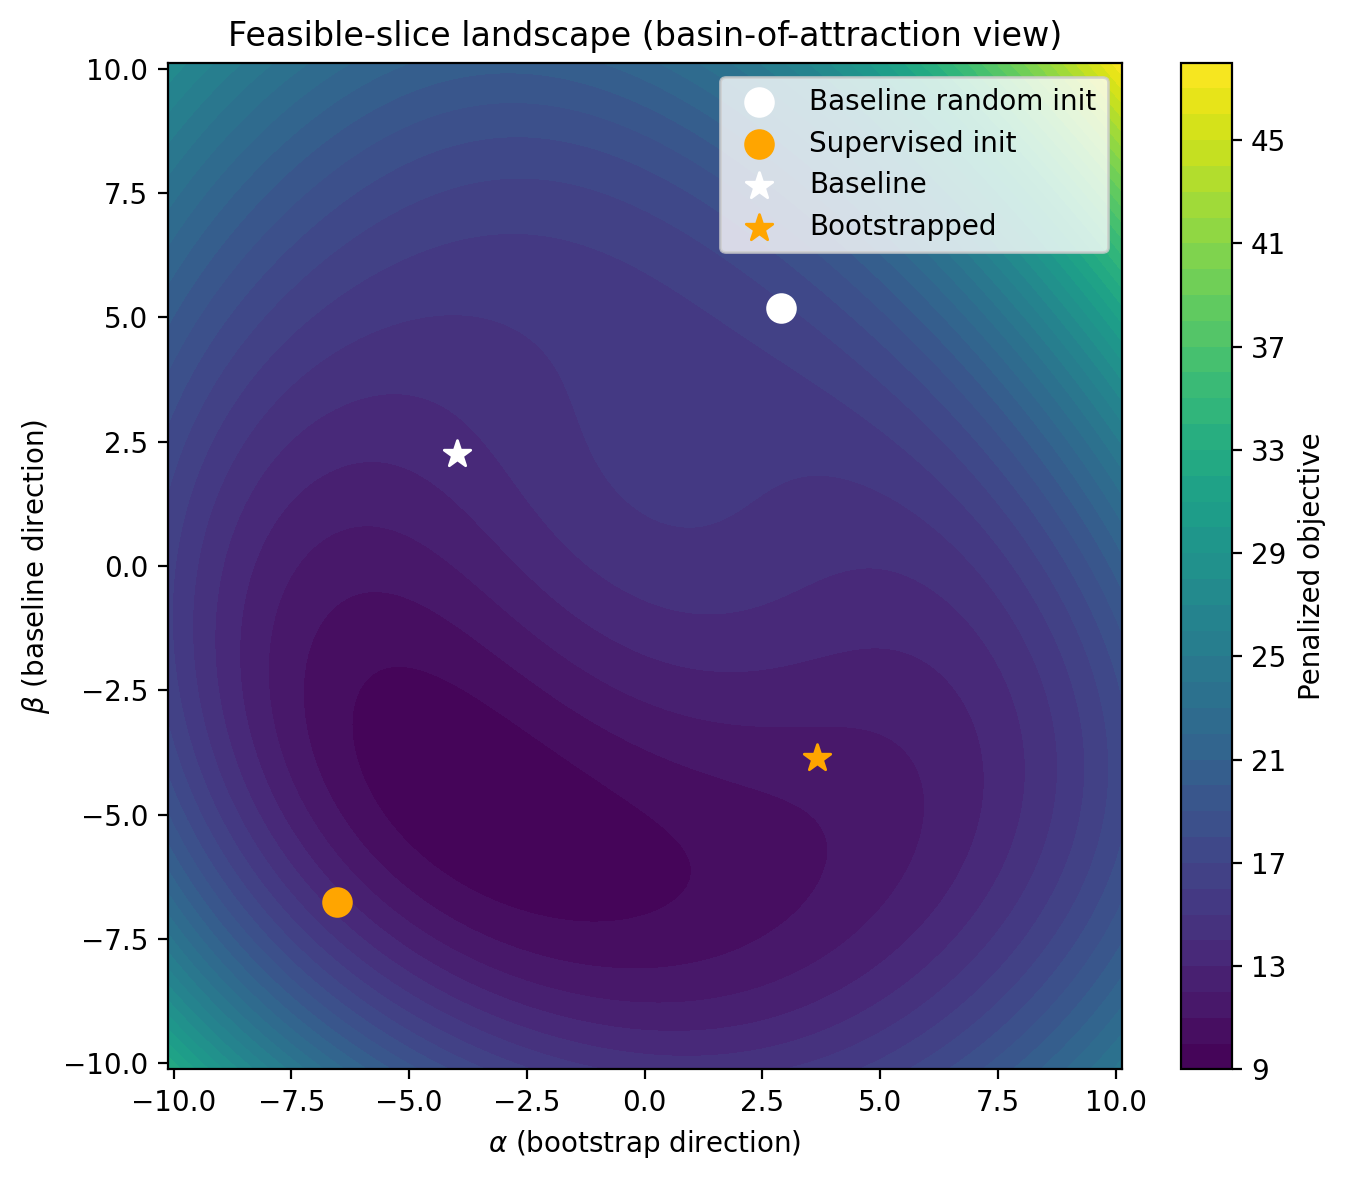

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6), dpi=200)
cs = plt.contourf(AA, BB, Z, levels=40)
plt.colorbar(cs, label="Penalized objective")

plt.scatter(a_base0, b_base0, c="white", s=100, label="Baseline random init")
plt.scatter(a_sup, b_sup, c="orange", s=100, label="Supervised init")
plt.scatter(a_base, b_base, c="white", s=100, marker="*", label="Baseline")
plt.scatter(a_boot, b_boot, c="orange", s=100, marker="*", label="Bootstrapped")

plt.xlabel(r"$\alpha$ (bootstrap direction)")
plt.ylabel(r"$\beta$ (baseline direction)")
plt.legend()
plt.title("Feasible-slice landscape (basin-of-attraction view)")
plt.tight_layout()
plt.show()